In [1]:
# Random Forest with a dataset (Iris)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
# 1) Load dataset
data = load_iris()

X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 112
Test samples: 38


In [6]:
# 2) Fit baseline Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# 3) Evaluate performance
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nRandom Forest Accuracy:", round(acc, 4))
print("Confusion Matrix:\n", cm)


Random Forest Accuracy: 0.9211
Confusion Matrix:
 [[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]


In [8]:
# 4) Simple parameter tuning (n_estimators)
best_acc = 0
best_n = None

for n in [20, 50, 100, 200]:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    acc_n = accuracy_score(y_test, pred)

    print(f"n_estimators={n}: accuracy={acc_n:.4f}")

    if acc_n > best_acc:
        best_acc = acc_n
        best_n = n

print(f"\nBest n_estimators selected: {best_n}")

n_estimators=20: accuracy=0.8947
n_estimators=50: accuracy=0.9211
n_estimators=100: accuracy=0.9211
n_estimators=200: accuracy=0.8947

Best n_estimators selected: 50


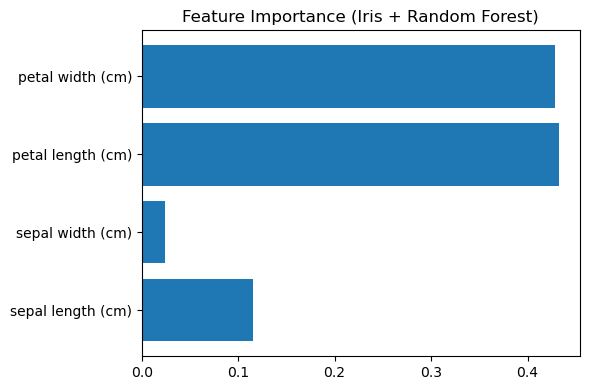

In [9]:
# 5) Feature importance
importances = rf.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(feature_names, importances)
plt.title("Feature Importance (Iris + Random Forest)")
plt.tight_layout()
plt.show()